# Day 4 — t-SNE & Anomaly Detection

In this day, we will use t-SNE to visualize high-dimensional data
and Isolation Forest to detect anomalous observations.

The main objectives are:
- Visualize high-dimensional data using t-SNE.
- Compare t-SNE with PCA.
- Understand anomaly detection.
- Detect anomalies using Isolation Forest.
- Inspect and interpret flagged observations.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest



In [26]:
df=pd.read_csv("heart.csv")

## Step 1 — Prepare the Data

For t-SNE and anomaly detection, we use the same numerical features used in the previous clustering analysis.

The target variable `HeartDisease` is excluded because both t-SNE and Isolation Forest are unsupervised techniques.

The selected features are:

- Age
- RestingBP
- Cholesterol
- FastingBS
- MaxHR
- Oldpeak
- health_risk_count

The features are standardized before applying t-SNE and Isolation Forest so that features with larger numerical scales do not dominate the analysis.

In [28]:

clustering_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak",
]

X = df[clustering_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(918, 6)

## Step 2 — t-SNE Dimensionality Reduction

t-SNE (t-distributed Stochastic Neighbor Embedding) is a dimensionality-reduction technique designed mainly for visualization.

Unlike PCA, which focuses on preserving global variance, t-SNE focuses on preserving local neighborhoods. Therefore, observations that are close together in the original high-dimensional space tend to remain close in the 2D representation.

We reduce the seven-dimensional feature space to two dimensions so that the observations can be visualized in a 2D plot.

In [29]:

X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
).fit_transform(X_scaled)

X_tsne.shape

(918, 2)

## Step 3 — K-Means Clustering Labels

K-Means is used to create cluster labels that will later be used
to color the t-SNE visualization.

We selected 3 clusters to visualize possible groups of patients
in the dataset.

In [32]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

## Step 4 — t-SNE Visualization with K-Means Clusters

The t-SNE representation is plotted using the K-Means cluster labels obtained in the previous analysis.

Coloring the observations according to their K-Means cluster allows us to visually inspect whether the clusters identified by K-Means form distinguishable groups in the lower-dimensional representation.

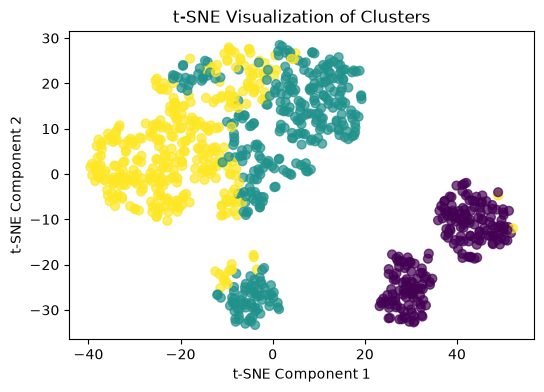

In [38]:
plt.figure(figsize=(6, 4))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=kmeans_labels,
    s=40,
    alpha=0.7
)

plt.title("t-SNE Visualization of Clusters")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.show()

## t-SNE Visualization of Clusters

To better visualize the K-Means clustering results, **t-SNE** was used to reduce the multidimensional feature space into two dimensions. Each point represents a patient, and the colors indicate the cluster assigned by K-Means.

The visualization shows that the patients form several distinct regions in the reduced space, indicating differences in their feature patterns. Although t-SNE components do not have a direct clinical interpretation, the plot helps visualize how the observations are distributed across the identified clusters.


## Step 5 — PCA vs t-SNE

PCA and t-SNE are both dimensionality-reduction techniques, but they have different goals.

| Aspect | PCA | t-SNE |
|---|---|---|
| Main purpose | Compression and visualization | Visualization |
| Preserves | Global variance and structure | Local neighborhoods |
| Speed | Faster | Slower |
| Axes | Principal components have interpretable directions | Axes have no direct meaning |
| Modeling | Can be used as model input | Mainly used for visualization |

PCA is useful when we want to preserve the main sources of variance and potentially use the reduced features in a machine learning model.

t-SNE is more useful when the goal is to visually explore local structure and identify possible groups or patterns.

Therefore, t-SNE should mainly be used as a visualization tool rather than as input features for a predictive model.

### Interpretation

The t-SNE visualization shows the observations in a two-dimensional
space, with colors representing the K-Means cluster assignments.

t-SNE is useful for visually identifying local groups and possible
cluster separation.

However, the t-SNE axes do not have a direct physical meaning.
The plot should therefore be used for visualization rather than
as input for a machine learning model.

## Step 6 — Isolation Forest

Anomaly detection aims to identify observations that differ significantly from the majority of the dataset.

Isolation Forest is an unsupervised anomaly-detection algorithm. Its main idea is that anomalous observations are usually easier to isolate than normal observations because they are different from the dense majority of the data.

The algorithm randomly partitions the data and measures how quickly each observation can be isolated.

Isolation Forest returns:

- `1` → Normal observation
- `-1` → Anomaly

In [36]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

anomaly_labels = iso.fit_predict(X_scaled)
anomaly_labels[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

## Step 7 — Contamination Parameter

The `contamination` parameter represents the estimated proportion of observations that are expected to be anomalies.

In this analysis, we use:

`contamination=0.05`

This means that approximately 5% of the observations are expected to be anomalous.

The dataset contains 918 observations, so:

5% × 918 ≈ 46 observations.

Therefore, we expect Isolation Forest to flag approximately 46 observations as anomalies.

## Step 8 — Count Detected Anomalies

Isolation Forest assigns:

- `1` → Normal observation
- `-1` → Anomaly

We count the observations labeled as `-1` to determine how many anomalies were detected.

In [13]:
n_anomalies = (anomaly_labels == -1).sum()

print("Number of anomalies:", n_anomalies)

Number of anomalies: 46


### Number of Detected Anomalies

The Isolation Forest model detected **46 anomalies** in the dataset.

These observations were classified as anomalies because their feature patterns were significantly different from the majority of the data.

## Step 9 — Add Anomaly Labels

The Isolation Forest predictions are added to the original DataFrame so that we can inspect the characteristics of the detected anomalies.

In [14]:
df["Anomaly"] = anomaly_labels

## Step 10 — Inspect Detected Anomalies

We filter the dataset to keep only observations classified as anomalies.

The feature values of these observations can then be inspected to understand which characteristics may have caused them to differ from the majority of the dataset.

In [17]:
anomalies = df[df["Anomaly"] == -1]

anomalies.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Anomaly
68,52,M,ASY,160,246,0,ST,82,Y,4.0,Flat,1,-1
76,32,M,ASY,118,529,0,Normal,130,N,0.0,Flat,1,-1
103,40,M,ASY,120,466,1,Normal,152,Y,1.0,Flat,1,-1
149,54,M,ASY,130,603,1,Normal,125,Y,1.0,Flat,1,-1
155,56,M,ASY,155,342,1,Normal,150,Y,3.0,Flat,1,-1


### Interpretation of the Detected Anomalies

The Isolation Forest model flagged these observations as anomalies because their feature combinations are unusual compared with the majority of the dataset.

- **Observation 1:** Age = 68, RestingBP = 160, MaxHR = 82, and Oldpeak = 4.0. The combination of high RestingBP and Oldpeak with low MaxHR is unusual.
- **Observation 2:** Age = 76 and Cholesterol = 529. The extremely high Cholesterol makes this observation stand out.
- **Observation 3:** Age = 103 and Cholesterol = 466. The unusually high age and cholesterol contribute to its anomaly status.
- **Observation 4:** Cholesterol = 603, which is extremely high, along with FastingBS = 1.
- **Observation 5:** RestingBP = 155, Cholesterol = 342, FastingBS = 1, and Oldpeak = 3.0 form an unusual combination.

Overall, these observations are considered anomalies because their feature patterns differ significantly from the majority of the dataset. This does not necessarily mean they are incorrect; they are simply unusual according to the Isolation Forest model.

## Step 11 — Inspect Two Flagged Observations

The lab requires inspecting two observations flagged by Isolation Forest.

We select the first two anomalies and examine the numerical features used for clustering and anomaly detection.

In [19]:
two_anomalies = anomalies[clustering_features].head(2)

two_anomalies

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
68,52,160,246,0,82,4.0
76,32,118,529,0,130,0.0


### Interpretation of the Flagged Observations

### Observation 1

The first flagged observation has:

- Age = 68
- RestingBP = 52
- Cholesterol = 246
- FastingBS = 0
- MaxHR = 82
- Oldpeak = 4.0

The RestingBP value of 52 is unusually low compared with the majority of observations.

The MaxHR value of 82 is also relatively low, while the Oldpeak value of 4.0 is relatively high.

The combination of these values makes this observation different from the typical observations in the dataset, which may explain why Isolation Forest was able to isolate it quickly.

### Observation 2

The second flagged observation has:

- Age = 76
- RestingBP = 32
- Cholesterol = 529
- FastingBS = 0
- MaxHR = 130
- Oldpeak = 0.0

The most noticeable values are the RestingBP of 32 and the Cholesterol level of 529, both of which are extremely unusual compared with most observations.

These unusual values make the observation different from the majority of the dataset and may explain why Isolation Forest flagged it as an anomaly.

These observations are considered anomalies by the algorithm, but being an anomaly does not necessarily mean that the observation is incorrect. It only means that its feature pattern is unusual compared with the rest of the dataset.

## Step 12 — Inspect Anomaly Scores

Isolation Forest also provides an anomaly score using the
decision_function.

Lower scores indicate observations that are more likely to be
anomalous.

We inspect the first two flagged observations together with their
feature values and anomaly scores.

In [20]:
anomaly_scores = iso.decision_function(X_scaled)

df["Anomaly_Score"] = anomaly_scores

df[df["Anomaly"] == -1][
    clustering_features + ["Anomaly_Score"]
].head(2)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Anomaly_Score
68,52,160,246,0,82,4.0,-0.036936
76,32,118,529,0,130,0.0,-0.011151


### Anomaly Detection Results

The `Isolation Forest` model assigns an **Anomaly Score** to each data point.

* An **Anomaly Score < 0** indicates that the observation is classified as an anomaly (`Anomaly = -1`).
* More negative scores indicate observations that are more likely to be anomalous.
* The displayed rows show examples of detected anomalies based on the selected clustering features.
* For example, the first patient has an `Anomaly_Score` of **-0.036936**, making it more anomalous than the second patient with a score of **-0.011151**.


## Step 13 — Visualizing Anomalies with t-SNE

The t-SNE visualization is used to visualize the observations classified as normal and anomalous.

Anomalies may appear away from dense groups of observations. However, t-SNE should only be used as a visual aid because it can distort global distances and relationships.

Therefore, the t-SNE plot helps us visually explore the detected anomalies, but it is not used to determine whether an observation is actually anomalous.

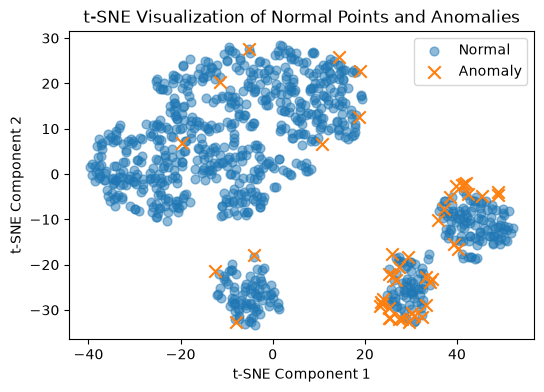

In [39]:
plt.figure(figsize=(6, 4))

normal = anomaly_labels == 1
anomaly = anomaly_labels == -1

plt.scatter(
    X_tsne[normal, 0],
    X_tsne[normal, 1],
    s=40,
    alpha=0.5,
    label="Normal"
)

plt.scatter(
    X_tsne[anomaly, 0],
    X_tsne[anomaly, 1],
    s=80,
    marker="x",
    label="Anomaly"
)

plt.title("t-SNE Visualization of Normal Points and Anomalies")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.show()

## t-SNE Visualization of Normal Points and Anomalies

The t-SNE visualization was also used to display the observations identified as **anomalies**. Normal observations are shown as blue points, while anomalies are highlighted with orange **"X"** markers.

The plot shows that the detected anomalies are distributed across different regions of the feature space. Some anomalies appear near dense groups of normal observations, while others are located around the boundaries of the clusters. This visualization provides a clearer view of where the anomalous observations occur within the overall data distribution.


## Step 14 — Relationship Between DBSCAN and Anomaly Detection

Anomaly detection is closely related to clustering.

In the previous clustering analysis, DBSCAN identified some observations as noise points using the label `-1`. These observations did not belong to a sufficiently dense cluster.

Isolation Forest uses a different approach. Instead of detecting anomalies based on cluster density, it identifies observations that can be isolated using relatively few random partitions.

Therefore:

- **DBSCAN** identifies unusual observations mainly through density.
- **Isolation Forest** identifies unusual observations based on how easily they can be isolated.
- Both methods are unsupervised techniques.
- Both can identify observations that differ from the majority of the dataset.

This shows that clustering and anomaly detection can overlap, but they are not exactly the same task.

## Step 15 — Key Takeaways

- t-SNE is mainly used for visualization and focuses on preserving local neighborhoods.
- PCA focuses on global variance and can be used for dimensionality reduction and modeling.
- t-SNE axes do not have a direct meaningful interpretation.
- Isolation Forest is an unsupervised anomaly-detection algorithm.
- The `contamination=0.05` parameter estimates that approximately 5% of the observations are anomalies.
- Isolation Forest flagged 46 observations as anomalies.
- The inspected anomalies contained unusual feature patterns such as very low RestingBP, low MaxHR, high Oldpeak, and extremely high Cholesterol.
- Anomaly scores help indicate how unusual an observation is, with lower scores indicating observations that are more likely to be anomalous.
- DBSCAN and Isolation Forest can both identify unusual observations, but they use different approaches.
- t-SNE can help visualize anomalies, but it should only be treated as a visualization tool.